In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [53]:
using Revise
includet("./base.jl")
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [3]:
using JLD2
using DataFrames, DataFramesMeta

In [4]:
includet("../../../scripts/figures_util.jl")

In [5]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

In [65]:
f = jldopen("./data1.jld2")

fmetadata = f["metadata"]
Klips = fmetadata.Klips_to_run

# second index sets the Klip set, first index the run index
fparams = f["params"]
fode_fTs = f["ode_final_Ts"]
fpde_fTs = f["pde_final_Ts"]
fpde_fss = f["pde_final_states"]
fpde_rcs = f["pde_retcodes"]
fpde_dls = f["pde_dom_length"];

fr2_Lmax(Klips[ii]...) = 0.333333331848955
fpde_dls[ii, ri] = 0.17543859649122806


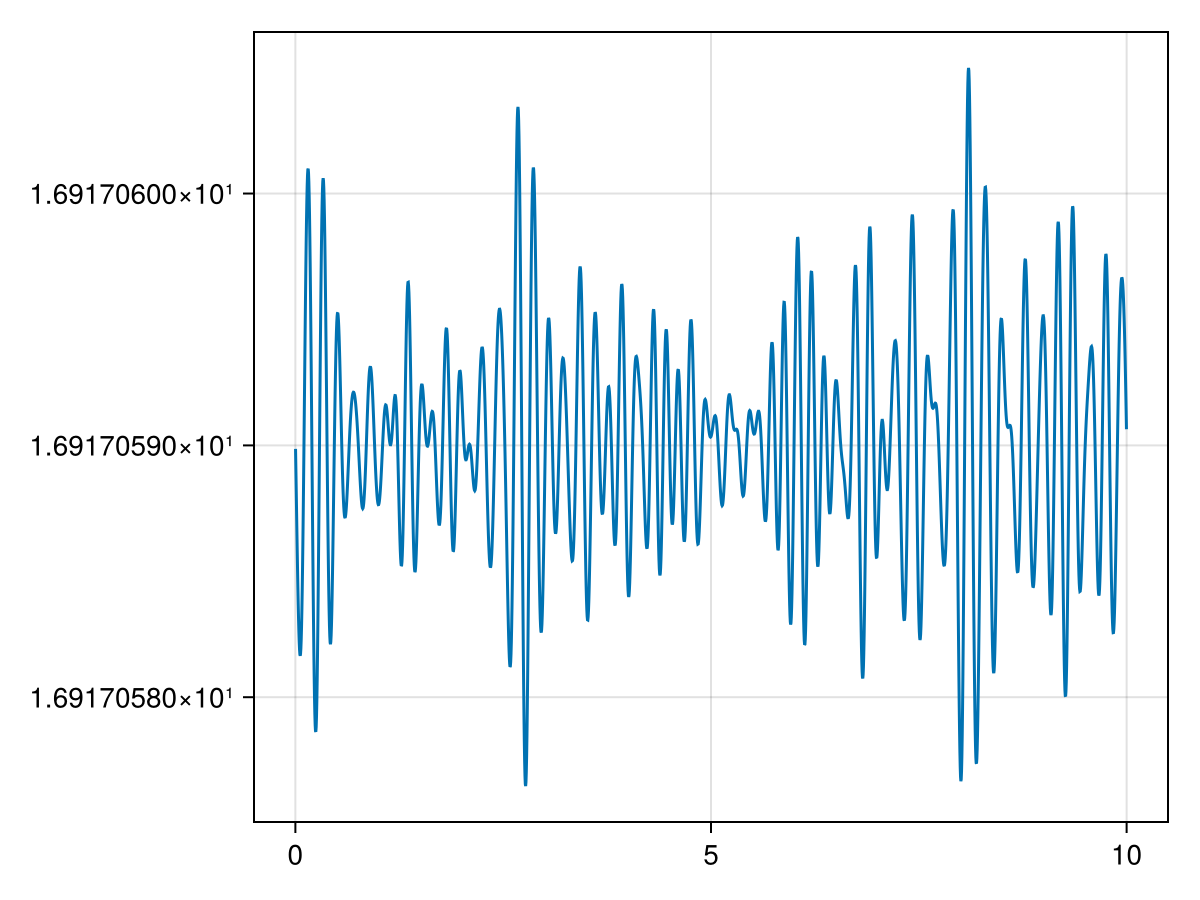

In [146]:
ii = 2
ri = 6
fs = fpde_fss[ii,ri]

@show fr2_Lmax(Klips[ii]...)
@show fpde_dls[ii,ri]

fap = lines(get_spatial_gridpoints_dx(fmetadata.sN, fmetadata.dx), get_total_biomass_1d(fs, fmetadata.N))
# display(GLMakie.Screen(), fap)
fap
# plot_spatial_fs(fs, fmetadata.N, fmetadata.sN, fmetadata.dx)

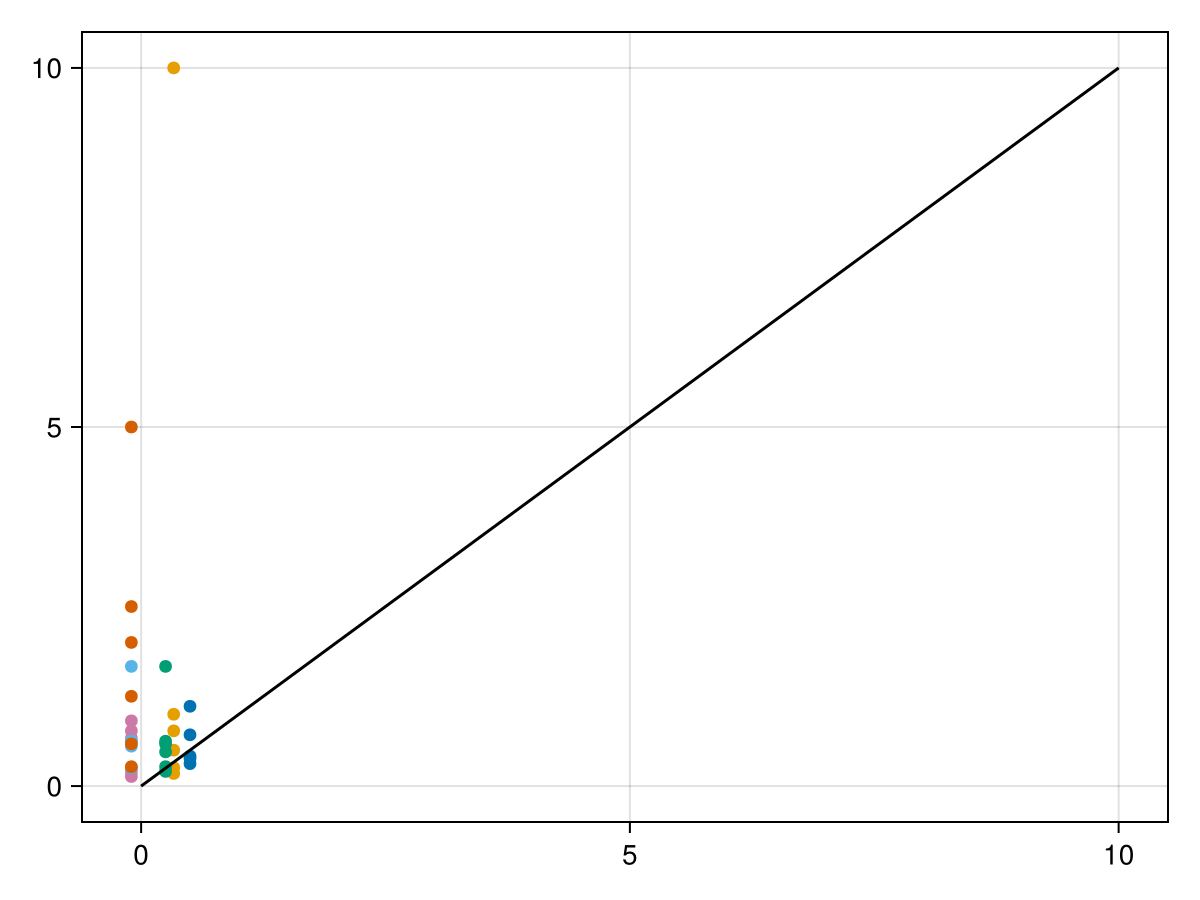

In [158]:
fig = Figure()
ax = Axis(fig[1,1])

Lmaxs = []
dls = []

for ii in 1:length(Klips)
    K, l, p = Klips[ii]
    Lmax = fr2_Lmax(K, l, p)
    
    valid_is = findall(==(ReturnCode.Terminated), fpde_rcs[ii,:])
    dls_ = fpde_dls[ii,valid_is]
    
    if !ismissing(Lmax)
        append!(Lmaxs, fill(Lmax, length(valid_is)))
        append!(dls, dls_)
    end
    
    if ismissing(Lmax)
        Lmax = -0.1
    end
    scatter!(ax, fill(Lmax, length(valid_is)), dls_)
end
lines!([0., 10.], [0., 10.]; color=:black)
# xlims!(ax, -0.15, 2.)
# ylims!(ax, -0.15, 2.)
# display(GLMakie.Screen(), fig)
fig

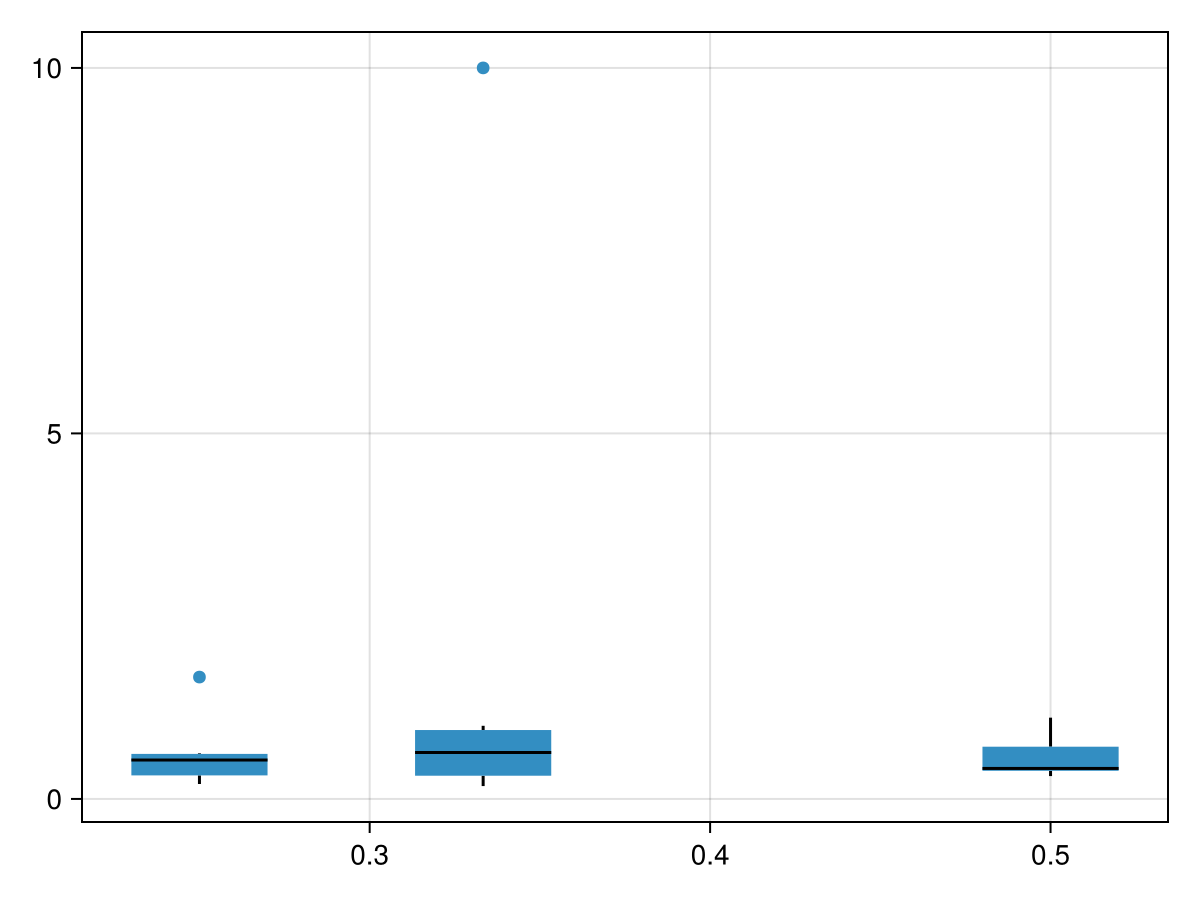

In [164]:
fap = boxplot(Lmaxs, dls; width=0.05)
display(GLMakie.Screen(), fap)
fap

In [34]:
fr2_Lmax(10, 1., 1.)

0.5492984972078943

In [43]:
map(fmetadata.Klips_to_run) do (K, l, p) MinimalModelV2.fr2_Lmax(K, l, p) end
map(fmetadata.Klips_to_run) do (K, l, p) K end

6-element Vector{Float64}:
 10.782736830354969
 15.176070792347483
 19.59437173444063
 10.782736830354969
 15.176070792347483
 19.59437173444063

In [9]:
keys(f)

11-element Vector{String}:
 "metadata"
 "params"
 "ode_retcodes"
 "ode_final_states"
 "ode_final_Ts"
 "linstab_mrls"
 "pde_u0s"
 "pde_retcodes"
 "pde_final_states"
 "pde_dom_length"
 "pde_final_Ts"